In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

In [6]:
# initial values 
X = np.array([[1.0, 3.0], [4.0, 10.0]])
y = np.array([5.0, 6.0])
m = np.array([-1.0, 2.0])
b = np.array([1.0, 1.0])
alpha = 0.01
n = len(y)  #nmber of data points = 2

print("Data is ready")
print("X =", X)
print("y =", y)
print("m =", m)
print("b =", b)

Data is ready
X = [[ 1.  3.]
 [ 4. 10.]]
y = [5. 6.]
m = [-1.  2.]
b = [1. 1.]


In [8]:
#calculates predictions
def predict(X, m, b):
    y_predict = X @ m + b
    return y_predict
#test it with the starting values
y_predict = predict(X, m, b)
print("predicted values =", y_predict)
print("real values =", y)

predicted values = [ 6. 17.]
real values = [5. 6.]


In [15]:
# calculates the error
def calculate_error(y, y_predict):
    error = y_predict - y     
    mse = np.mean(error ** 2)     #square the # then avearge them
    return error, mse

# test
error, mse = calculate_error(y, y_predict)
print("difference (y_predict - y) =", error )
print("MSE =", mse)

difference (y_predict - y) = [ 1. 11.]
MSE = 61.0


In [16]:
# calculates the gradients
#reduces the error
def calculate_gradients(X, error, n):
    grad_m = (2/n) * (X.T @ error)
    grad_b = (2/n) * error
    return grad_m, grad_b

#test
grad_m, grad_b = calculate_gradients(X, error, n)
print("gradient for m =", grad_m)
print("gradient for b =", grad_b)

gradient for m = [ 45. 113.]
gradient for b = [ 1. 11.]


In [17]:
# updating m and b using the gradients
def update(m, b, grad_m, grad_b, alpha):
    new_m = m - alpha * grad_m
    new_b = b - alpha * grad_b
    return new_m, new_b

#test
m, b = update(m, b, grad_m, grad_b, alpha)
print("updated m =", m)
print("updated b =", b)

updated m = [-1.45  0.87]
updated b = [0.99 0.89]


In [30]:
# resetting m andd b back to initial values
m = np.array([-1.0, 2.0])
b= np.array([1.0, 1.0])

# lists to store history 
m_history = [m.copy()]    # stores m after each iteration
b_history = [b.copy()]
error_history = [] 

# loop
for i in range(1,5):
    y_predict = predict(X, m, b)
    error, mse = calculate_error(y, y_predict)
    grad_m, grad_b = calculate_gradients(X, error, n)
    m, b = update(m, b, grad_m, grad_b, alpha)

# save for the graphs
m_history.append(m.copy())
b_history.append(b.copy())
error_history.append(mse)

print(f"Iteration {i}:")
print(f"y_predict = {y_predict}")
print(f"error = {error}")
print(f"mse = {mse:.2f}")
print(f"grad_m = {grad_m}")
print(f"grad_b = {grad_b}")
print(f"new_m = {m}")
print(f"new_b = {b}")

Iteration 4:
y_predict = [2.954063 6.378335]
error = [-2.045937  0.378335]
mse = 2.16
grad_m = [-0.532597 -2.354461]
grad_b = [-2.045937  0.378335]
new_m = [-1.36371103  1.11912761]
new_b = [1.05681037 0.89486965]


In [25]:
# computing the derivative automatically
def mse_equation(params):
    m_ = params[0:2]    
    b_ = params[2:4]    
    y_predict = X @ m_ + b_
    mse = np.mean((y_predict - y) ** 2)
    return mse

def get_scipy_gradient(params):
    scipy_gradient = approx_fprime(params, mse_equation, 1e-6)
    return scipy_gradient

# test it with initial values
m_test = np.array([-1.0, 2.0])
b_test = np.array([1.0, 1.0])
params = np.concatenate([m_test, b_test])  # join m and b into one list

scipy_grad = get_scipy_gradient(params)
print("scipy gradient for m =", scipy_grad[0:2])
print("scipy gradient for b =", scipy_grad[2:4])

scipy gradient for m = [ 45.0000085  113.00005452]
scipy gradient for b = [ 1.0000005  11.00000051]


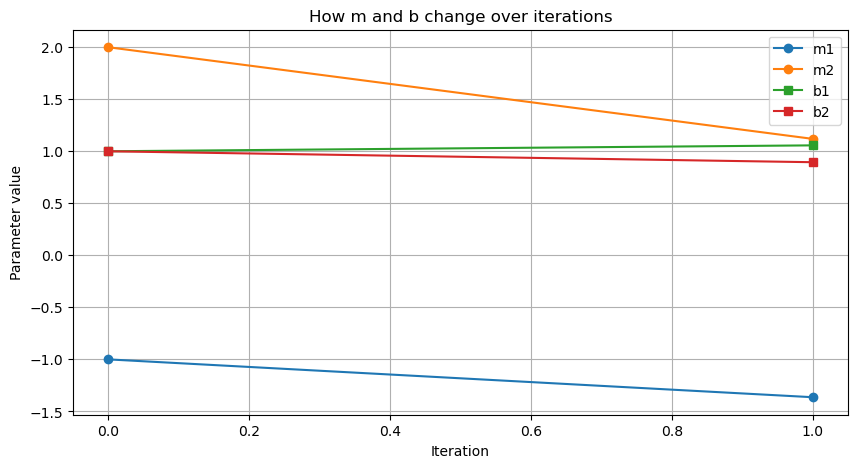

In [32]:
# Get the actual number of iterations from the history data
actual_iterations = len(m_history) 
# Create iterations array to match data length
iterations = np.arange(0, actual_iterations)  

# converting history to numpy arrays
m_hist = np.array(m_history)
b_hist = np.array(b_history)

# draws the graph
plt.figure(figsize=(10, 5))

plt.plot(iterations, m_hist[:, 0], marker="o", label="m1")
plt.plot(iterations, m_hist[:, 1], marker="o", label="m2")
plt.plot(iterations, b_hist[:, 0], marker="s", label="b1")
plt.plot(iterations, b_hist[:, 1], marker="s", label="b2")

plt.title("How m and b change over iterations")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.legend()    # shows the labels (m1, m2, b1, b2)
plt.grid(True)  # adds grid lines to make it easier to read
plt.show()      # display the graph